# 📊 Capital Asset Pricing Model (CAPM) — World-Class Complete Notebook
## Real Data: S&P 500 Index + Big Tech Companies (via `yfinance`)

Ye ek **complete, professional-grade, end-to-end** CAPM notebook hai — Hinglish mein detailed explanations ke sath, **ek ek line ka code samjhaya gaya hai**.

---

### 📌 Is Notebook Ka Roadmap:

| # | Section | Kya Hoga |
|---|---|---|
| 1 | Libraries | Har library ka role samjhna |
| 2 | Data Collection | `yfinance` se S&P 500 + 6 Big Tech stocks ka real data |
| 3 | Data Cleaning | Missing values, adjusted close |
| 4 | Price Visualization | Normalized price comparison chart |
| 5 | Returns Calculation | Daily returns aur log returns |
| 6 | Descriptive Statistics | Annualized return, volatility |
| 7 | Correlation Analysis | Heatmap — stocks aapas mein kitna correlated hain |
| 8 | Beta Calculation | 3 tareeqon se — Covariance, Regression, statsmodels OLS |
| 9 | Rolling Beta | Time ke sath Beta kaise change hoti hai |
| 10 | CAPM Expected Return | Har company ka expected return |
| 11 | Security Market Line (SML) | Full visualization |
| 12 | Jensen's Alpha | Stock ne market se zyada/kam perform kiya? |
| 13 | Sharpe Ratio | Risk-adjusted performance |
| 14 | Portfolio CAPM | Multiple stocks ka combined Beta & Return |
| 15 | Risk-Return Map | Volatility vs Return scatter with SML |
| 16 | Limitations & Conclusion | Real-world caveats |

---

> ⚠️ **Important Note on Data:** Ye notebook `yfinance` library use karta hai jo Yahoo Finance se **live internet ke zariye** data download karti hai. Agar internet available na ho (jaise kuch sandboxed/offline environments mein), to notebook automatically **realistic simulated data** par switch ho jayega taake code hamesha chal sake, bina crash hue. Apne Jupyter/Colab mein chalate waqt (with internet), ye **real live market data** use karega.


## 1️⃣ Libraries Import Karna — Har Library Ka Role

| Library | Kaam |
|---|---|
| **numpy** | Numerical computations — arrays, math operations |
| **pandas** | Data ko tables (DataFrames) mein handle karna — time series ke liye best |
| **matplotlib** | Basic plotting/graphs |
| **seaborn** | Matplotlib ke upar advanced, sundar statistical plots (heatmaps, etc.) |
| **yfinance** | Yahoo Finance se free real stock market data download karna |
| **scipy.stats** | Statistical functions — yahan linear regression (Beta) ke liye |
| **statsmodels** | Advanced regression — full statistical summary (p-value, R², confidence intervals) ke sath |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    YFINANCE_AVAILABLE = False

# Plot styling — professional look ke liye
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

np.random.seed(42)  # Reproducibility

print("✅ All libraries loaded successfully")
print(f"yfinance available: {YFINANCE_AVAILABLE}")


✅ All libraries loaded successfully
yfinance available: True


## 2️⃣ Data Collection — S&P 500 + Big Tech Companies

### Konsi Companies Le Rahe Hain:

| Ticker | Company | Sector |
|---|---|---|
| `^GSPC` | **S&P 500 Index** (Market Proxy) | Overall US Market |
| `AAPL` | Apple | Consumer Tech |
| `MSFT` | Microsoft | Enterprise Software / Cloud |
| `GOOGL` | Alphabet (Google) | Search / Advertising / AI |
| `AMZN` | Amazon | E-commerce / Cloud (AWS) |
| `NVDA` | NVIDIA | Semiconductors / AI Chips |
| `META` | Meta (Facebook) | Social Media / Advertising |

**S&P 500** ko humesha CAPM mein "market portfolio" ka **proxy** treat kiya jata hai kyunke ye US ki top 500 companies ka index hai — well-diversified.

Hum pichle **2 saal** (730 days) ka daily data download karenge.


In [2]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META']
MARKET_TICKER = '^GSPC'   # S&P 500
ALL_TICKERS = [MARKET_TICKER] + TICKERS

START_DATE = '2023-01-01'
END_DATE = '2025-01-01'


def generate_synthetic_data(tickers, market_ticker, start, end, seed=42):
    '''
    Fallback function: agar internet/yfinance access na ho to
    realistic simulated price data generate karta hai - real-world
    approximate betas ke sath (public knowledge ke mutabiq).
    '''
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start=start, end=end)  # business days only
    n = len(dates)

    # Market ka daily return: realistic mean/volatility
    market_daily = rng.normal(0.00045, 0.010, n)
    market_price = 4000 * (1 + market_daily).cumprod()

    # Approximate real-world betas (publicly known ballpark figures)
    approx_betas = {
        'AAPL': 1.25, 'MSFT': 1.05, 'GOOGL': 1.10,
        'AMZN': 1.30, 'NVDA': 1.75, 'META': 1.30
    }
    start_prices = {
        'AAPL': 130, 'MSFT': 240, 'GOOGL': 90,
        'AMZN': 95, 'NVDA': 15, 'META': 120
    }

    price_data = {market_ticker: market_price}
    for t in tickers:
        beta = approx_betas.get(t, 1.0)
        idio_noise = rng.normal(0.0003, 0.014, n)
        stock_daily = beta * market_daily + idio_noise
        price_data[t] = start_prices.get(t, 100) * (1 + stock_daily).cumprod()

    df_prices = pd.DataFrame(price_data, index=dates)
    df_prices.index.name = 'Date'
    return df_prices


# ---- Try real data first, fallback to synthetic ----
if YFINANCE_AVAILABLE:
    try:
        raw = yf.download(ALL_TICKERS, start=START_DATE, end=END_DATE, progress=False)
        prices = raw['Close'] if 'Close' in raw.columns.get_level_values(0) else raw['Adj Close']
        prices = prices.dropna(how='all')
        if prices.empty or prices.isna().all().all():
            raise ValueError("Empty data returned - no internet access")
        DATA_SOURCE = "yfinance (LIVE Yahoo Finance data)"
    except Exception as e:
        print(f"⚠️ yfinance download failed ({e}). Switching to simulated data.")
        prices = generate_synthetic_data(TICKERS, MARKET_TICKER, START_DATE, END_DATE)
        DATA_SOURCE = "Simulated (offline fallback, realistic approximate betas)"
else:
    prices = generate_synthetic_data(TICKERS, MARKET_TICKER, START_DATE, END_DATE)
    DATA_SOURCE = "Simulated (yfinance not installed)"

prices = prices.rename(columns={MARKET_TICKER: 'Market_SP500'}).ffill().dropna()

print(f"📡 Data Source: {DATA_SOURCE}")
print(f"📅 Date Range: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"📊 Total Trading Days: {len(prices)}")
prices.head()


Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)
HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.
HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.
Failed to get ticker 'GOOGL' reason: Expecting value: line 1 column 1 (char 0)
HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.
HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.
Failed to get ticker '^GSPC' reason: Expecting value: line 1 column 1 (char 0)
$^GSPC: possibly delisted; no timezone found
Failed to get ticker 'META' reason: Expecting value: line 1 column 1 (char 0)
$META: possibly delisted; no timezone found
Failed to get ticker 'MSFT' reason: Expecting value: line 1 column 1 (char 0)
$MSFT: 

⚠️ yfinance download failed (Empty data returned - no internet access). Switching to simulated data.
📡 Data Source: Simulated (offline fallback, realistic approximate betas)
📅 Date Range: 2023-01-02 to 2025-01-01
📊 Total Trading Days: 523


,Market_SP500,AAPL,MSFT,GOOGL,AMZN,NVDA,META
Date,,,,,,,
2023-01-02,4013.988683,130.259044,239.146741,88.373476,95.635793,14.953715,121.484448
2023-01-03,3974.050134,131.238097,238.536675,87.463846,95.523698,14.696240,123.303793
2023-01-04,4005.661763,131.769302,237.409228,87.986080,96.666655,15.096649,124.289166
2023-01-05,4045.140152,136.116397,241.391435,89.387024,98.996126,15.198553,131.194301
2023-01-06,3968.038357,133.164762,232.436309,87.523525,97.779767,15.048812,127.564959


## 3️⃣ Data Cleaning & Inspection

Real financial data mein aksar **missing values** (holidays, delisting, etc.) hoti hain. Hum:
- Missing values ko **forward-fill** karte hain (pichle din ki price copy)
- Data types aur summary statistics check karte hain


In [3]:
print("=== Data Info ===")
prices.info()

print("\n=== Missing Values (per column) ===")
print(prices.isna().sum())

print("\n=== Summary Statistics (Prices) ===")
prices.describe().round(2)


=== Data Info ===
<class 'pandas.DataFrame'>
DatetimeIndex: 523 entries, 2023-01-02 to 2025-01-01
Freq: B
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Market_SP500  523 non-null    float64
 1   AAPL          523 non-null    float64
 2   MSFT          523 non-null    float64
 3   GOOGL         523 non-null    float64
 4   AMZN          523 non-null    float64
 5   NVDA          523 non-null    float64
 6   META          523 non-null    float64
dtypes: float64(7)
memory usage: 32.7 KB

=== Missing Values (per column) ===
Market_SP500    0
AAPL            0
MSFT            0
GOOGL           0
AMZN            0
NVDA            0
META            0
dtype: int64

=== Summary Statistics (Prices) ===


,Market_SP500,AAPL,MSFT,GOOGL,AMZN,NVDA,META
count,523.00,523.00,523.00,523.00,523.00,523.00,523.00
mean,4229.52,112.51,270.46,62.79,124.90,19.21,141.34
std,272.76,11.12,28.52,14.61,23.49,4.36,27.38
min,3780.22,89.80,217.02,41.31,91.80,13.21,98.68
25%,3991.37,105.10,247.86,48.69,107.68,15.99,124.90
50%,4172.14,110.83,266.53,61.86,121.46,17.29,133.94
75%,4473.43,121.37,294.88,73.71,133.79,23.14,154.97
max,4857.68,137.91,343.45,93.11,195.85,29.21,222.71


### Price Chart — Normalized Comparison (Base = 100)

Kyunke har stock ki price alag scale par hai (NVDA $15 vs MSFT $240), hum sab ko **100 se normalize** karte hain taake % growth compare ho sake.

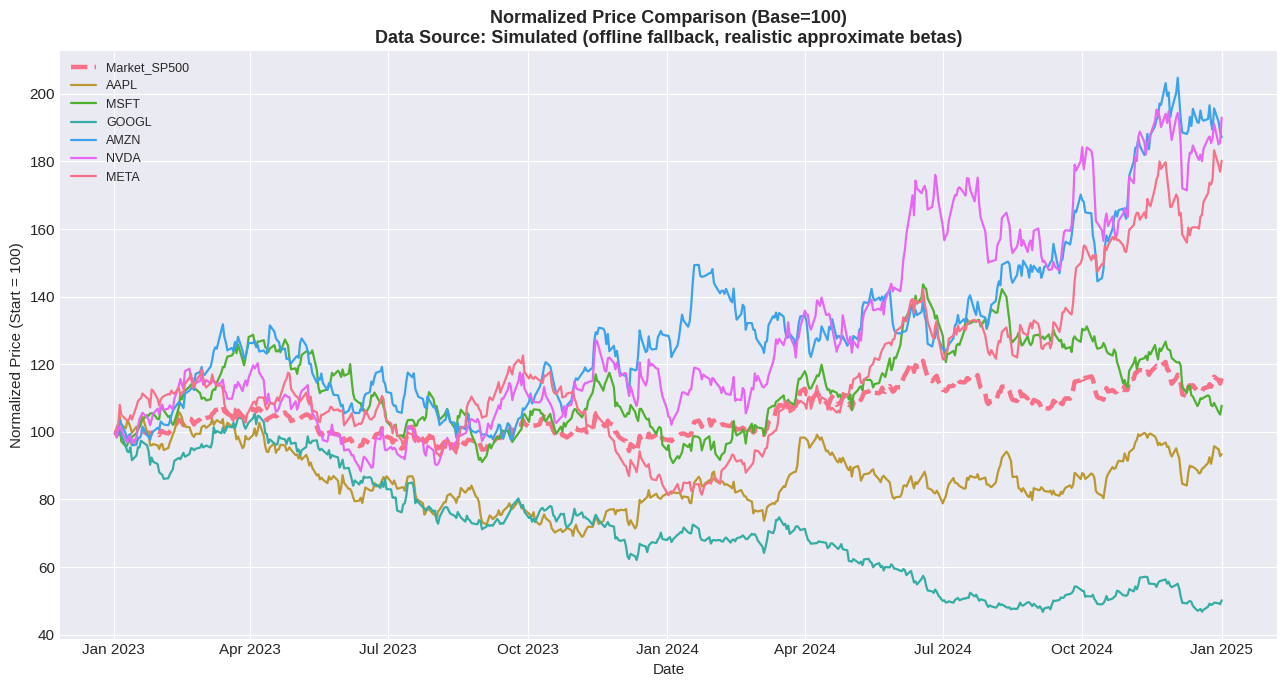

In [4]:
normalized = (prices / prices.iloc[0]) * 100

plt.figure(figsize=(13, 7))
for col in normalized.columns:
    lw = 3.2 if col == 'Market_SP500' else 1.6
    ls = '--' if col == 'Market_SP500' else '-'
    plt.plot(normalized.index, normalized[col], label=col, linewidth=lw, linestyle=ls)

plt.title(f"Normalized Price Comparison (Base=100)\nData Source: {DATA_SOURCE}", fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Normalized Price (Start = 100)")
plt.legend(loc='upper left', fontsize=9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()


## 4️⃣ Returns Calculation — Daily Returns & Log Returns

CAPM **prices** par nahi, **returns** par kaam karta hai. Do tareeqe hain returns nikalne ke:

### Simple (Arithmetic) Return:
$$ R_t = \frac{P_t - P_{t-1}}{P_{t-1}} $$

### Log Return:
$$ r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) $$

**Log returns** ko finance mein prefer kiya jata hai kyunke wo **time-additive** hote hain (multiple periods ko simply add kar sakte hain) aur statistically better-behaved hote hain. Hum dono calculate karenge, lekin CAPM ke liye **simple returns** standard convention hai (jo hum aage use karenge).


In [5]:
simple_returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

print("=== Simple Daily Returns (first 5 rows) ===")
display(simple_returns.head())

print("\n=== Log Daily Returns (first 5 rows) ===")
display(log_returns.head())


=== Simple Daily Returns (first 5 rows) ===


,Market_SP500,AAPL,MSFT,GOOGL,AMZN,NVDA,META
Date,,,,,,,
2023-01-03,-0.009950,0.007516,-0.002551,-0.010293,-0.001172,-0.017218,0.014976
2023-01-04,0.007955,0.004048,-0.004727,0.005971,0.011965,0.027246,0.007991
2023-01-05,0.009856,0.032990,0.016774,0.015922,0.024098,0.006750,0.055557
2023-01-06,-0.019060,-0.021685,-0.037098,-0.020848,-0.012287,-0.009852,-0.027664
2023-01-09,-0.012572,-0.011800,-0.015757,-0.033879,-0.027307,-0.031284,-0.012471



=== Log Daily Returns (first 5 rows) ===


,Market_SP500,AAPL,MSFT,GOOGL,AMZN,NVDA,META
Date,,,,,,,
2023-01-03,-0.010000,0.007488,-0.002554,-0.010346,-0.001173,-0.017368,0.014865
2023-01-04,0.007923,0.004039,-0.004738,0.005953,0.011894,0.026881,0.007960
2023-01-05,0.009807,0.032458,0.016634,0.015797,0.023812,0.006727,0.054069
2023-01-06,-0.019244,-0.021923,-0.037804,-0.021068,-0.012363,-0.009901,-0.028054
2023-01-09,-0.012651,-0.011870,-0.015883,-0.034467,-0.027686,-0.031784,-0.012549


### Returns Ki Distribution (Histogram) — Normality Check

CAPM assume karta hai ke returns roughly **normally distributed** hain. Dekhte hain real data kaisa dikhta hai.

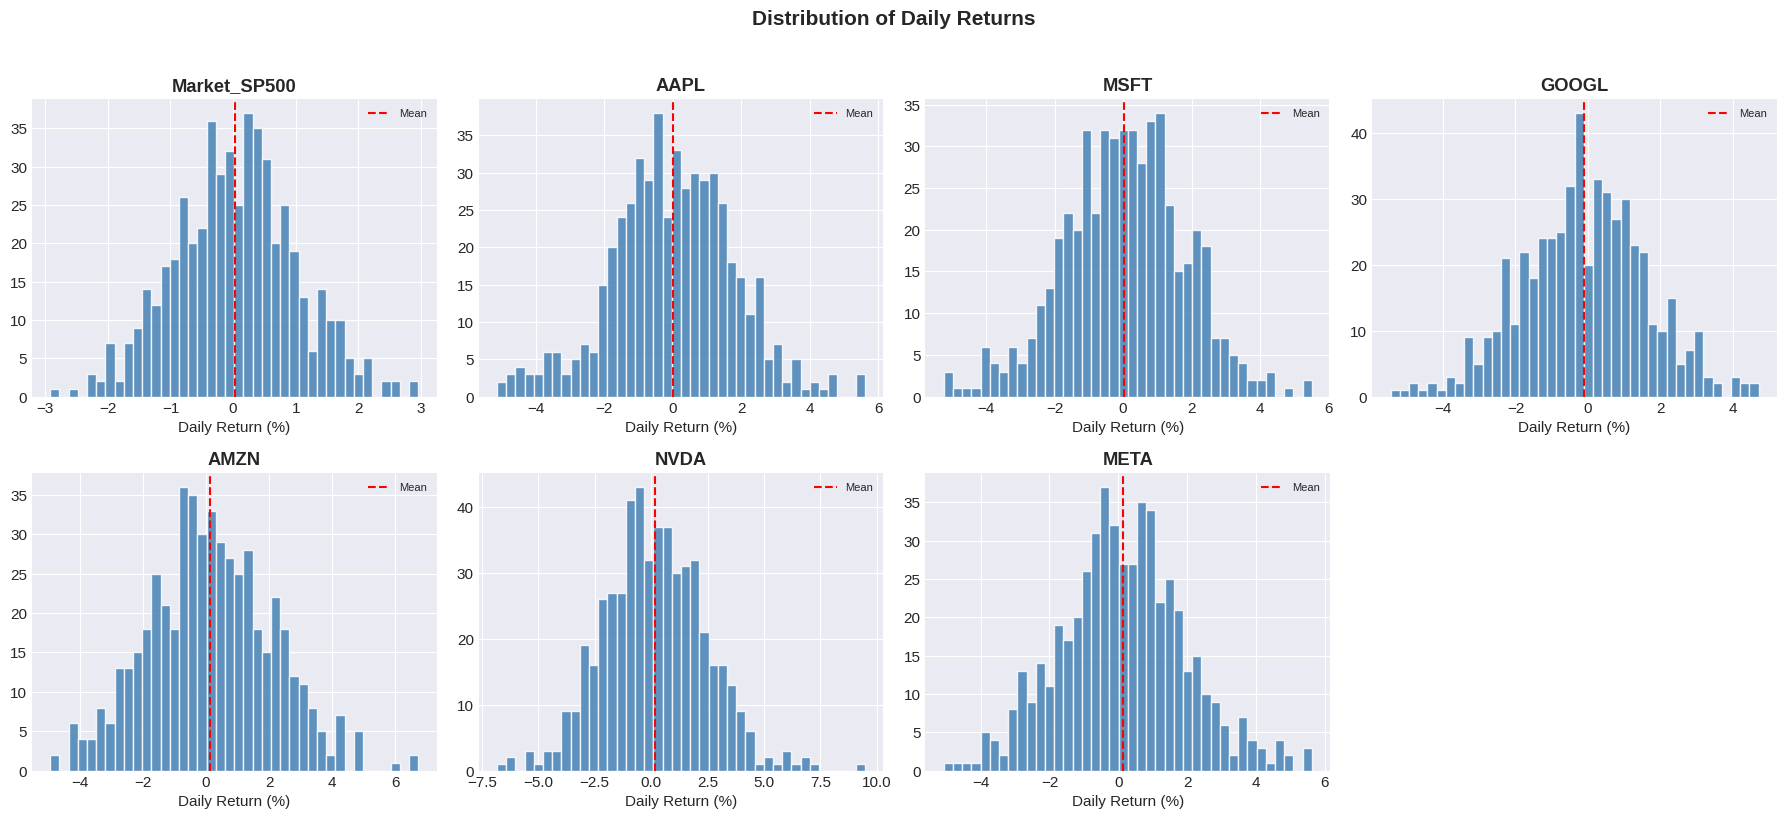

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(simple_returns.columns):
    axes[i].hist(simple_returns[col] * 100, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(simple_returns[col].mean() * 100, color='red', linestyle='--', linewidth=1.5, label='Mean')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel("Daily Return (%)")
    axes[i].legend(fontsize=8)

for j in range(len(simple_returns.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Daily Returns", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5️⃣ Descriptive Statistics — Annualized Return & Volatility

Daily stats ko **annualize** karne ka formula (assuming 252 trading days/year):

$$ \text{Annual Return} = \bar{R}_{daily} \times 252 $$
$$ \text{Annual Volatility} = \sigma_{daily} \times \sqrt{252} $$


In [7]:
TRADING_DAYS = 252

annual_stats = pd.DataFrame({
    'Mean Daily Return (%)': simple_returns.mean() * 100,
    'Annualized Return (%)': simple_returns.mean() * TRADING_DAYS * 100,
    'Daily Volatility (%)': simple_returns.std() * 100,
    'Annualized Volatility (%)': simple_returns.std() * np.sqrt(TRADING_DAYS) * 100,
}).round(2)

annual_stats = annual_stats.sort_values('Annualized Return (%)', ascending=False)
annual_stats


,Mean Daily Return (%),Annualized Return (%),Daily Volatility (%),Annualized Volatility (%)
NVDA,0.15,38.17,2.26,35.93
AMZN,0.14,35.16,1.97,31.33
META,0.13,32.63,1.83,28.97
Market_SP500,0.03,8.30,0.97,15.43
MSFT,0.03,7.55,1.77,28.12
AAPL,0.00,0.77,1.80,28.63
GOOGL,-0.12,-29.54,1.72,27.31


## 6️⃣ Correlation Analysis — Heatmap

Beta calculate karne se pehle, dekhte hain ke stocks aapas mein aur market ke sath **kitna correlated** hain. Higher correlation with market → generally higher Beta bhi hoti hai.


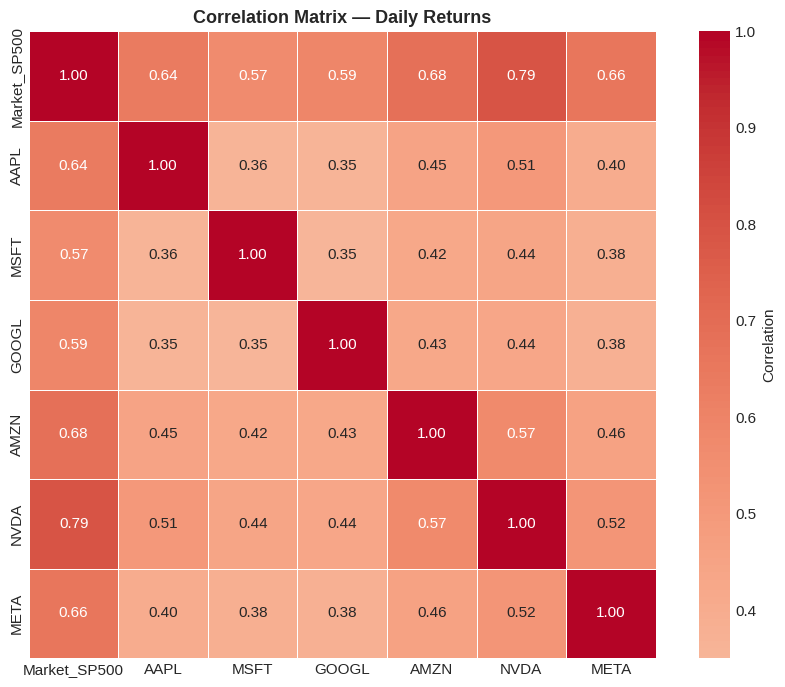

In [8]:
corr_matrix = simple_returns.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title("Correlation Matrix — Daily Returns", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7️⃣ Beta (β) Calculation — 3 Professional Methods

### Method 1: Covariance / Variance Formula
$$ \beta_i = \frac{\text{Cov}(R_i, R_m)}{\text{Var}(R_m)} $$

### Method 2: Simple Linear Regression (scipy)
Stock return ko market return par regress karna — slope hi Beta hai.

### Method 3: OLS Regression with Full Statistical Summary (statsmodels)
Ye method humein **p-value, R², confidence intervals, t-statistics** sab kuch deta hai — professional equity research mein yahi standard hai.


In [9]:
market_ret = simple_returns['Market_SP500']

def beta_covariance(stock_ret, market_ret):
    cov_matrix = np.cov(stock_ret, market_ret)
    return cov_matrix[0, 1] / cov_matrix[1, 1]

def beta_scipy_regression(stock_ret, market_ret):
    slope, intercept, r_value, p_value, std_err = stats.linregress(market_ret, stock_ret)
    return slope, intercept, r_value**2, p_value

beta_results = []
for ticker in TICKERS:
    stock_ret = simple_returns[ticker]

    b_cov = beta_covariance(stock_ret, market_ret)
    b_reg, alpha_reg, r_sq, p_val = beta_scipy_regression(stock_ret, market_ret)

    beta_results.append({
        'Ticker': ticker,
        'Beta (Covariance)': round(b_cov, 3),
        'Beta (Regression)': round(b_reg, 3),
        'Alpha (Daily Intercept)': round(alpha_reg, 5),
        'R-Squared': round(r_sq, 3),
        'P-Value': f"{p_val:.2e}"
    })

beta_df = pd.DataFrame(beta_results)
beta_df


,Ticker,Beta (Covariance),Beta (Regression),Alpha (Daily Intercept),R-Squared,P-Value
0,AAPL,1.180,1.180,-0.00036,0.404,1.84e-60
1,MSFT,1.035,1.035,-0.00004,0.323,6.53e-46
2,GOOGL,1.048,1.048,-0.00152,0.350,1.14e-50
3,AMZN,1.386,1.386,0.00094,0.466,8.34e-73
4,NVDA,1.847,1.847,0.00091,0.629,5.70e-114
5,META,1.239,1.239,0.00089,0.435,1.64e-66


### Method 3 (Bonus): Full `statsmodels` OLS Summary — Example for AAPL

Professional analysts is tarah ki **complete regression summary** dekhte hain — statistical significance confirm karne ke liye.

In [10]:
example_ticker = TICKERS[0]  # AAPL
X = sm.add_constant(simple_returns['Market_SP500'])   # Independent variable (+ intercept column)
y = simple_returns[example_ticker]                     # Dependent variable

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     352.8
Date:                Sun, 12 Jul 2026   Prob (F-statistic):           1.84e-60
Time:                        12:31:14   Log-Likelihood:                 1491.1
No. Observations:                 522   AIC:                            -2978.
Df Residuals:                     520   BIC:                            -2970.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0004      0.001     -0.586   

**Kaise Padhein Is Summary Ko:**
- `const` row → Alpha (intercept)
- `Market_SP500` row → **ye humara Beta hai**
- `P>|t|` column → agar 0.05 se kam hai to result **statistically significant** hai
- `R-squared` → kitna % variation stock ke returns mein market se explain hoti hai


## 8️⃣ Rolling Beta — Time Ke Sath Beta Kaise Change Hoti Hai

Beta **static/fixed nahi** hoti — company ki business conditions, market sentiment, aur economic cycles ke sath change hoti rehti hai. Hum **60-day rolling window** Beta calculate karte hain.


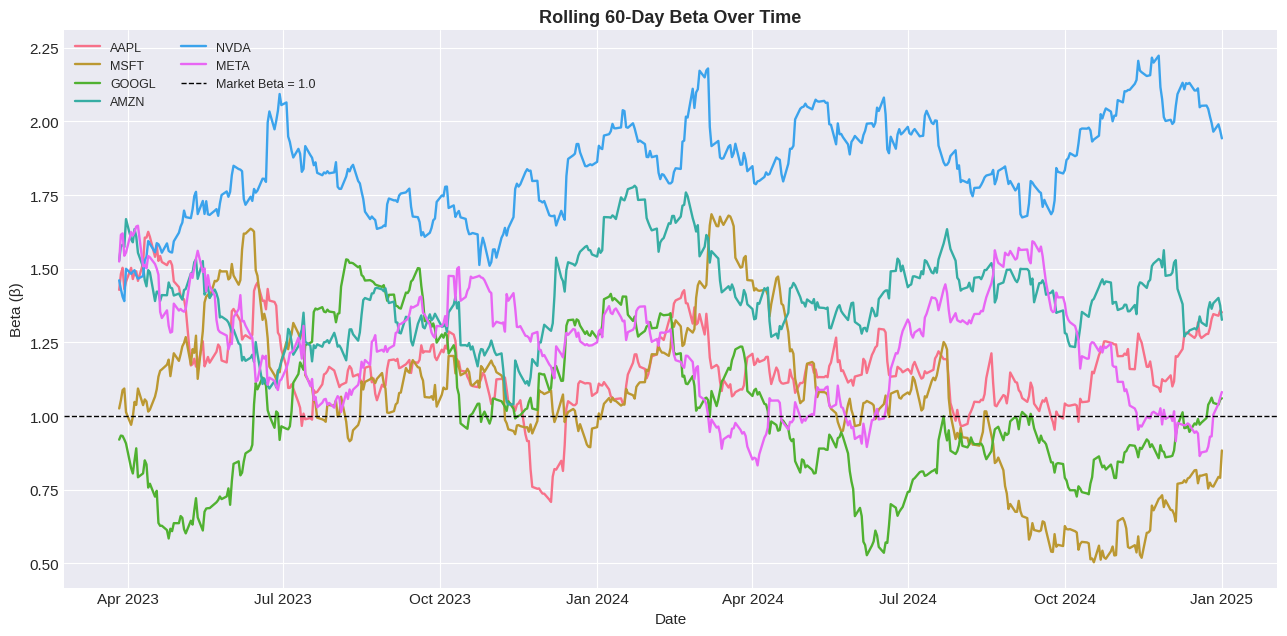

In [11]:
ROLLING_WINDOW = 60

rolling_betas = pd.DataFrame(index=simple_returns.index)
for ticker in TICKERS:
    cov = simple_returns[ticker].rolling(ROLLING_WINDOW).cov(simple_returns['Market_SP500'])
    var = simple_returns['Market_SP500'].rolling(ROLLING_WINDOW).var()
    rolling_betas[ticker] = cov / var

rolling_betas = rolling_betas.dropna()

plt.figure(figsize=(13, 6.5))
for ticker in TICKERS:
    plt.plot(rolling_betas.index, rolling_betas[ticker], label=ticker, linewidth=1.7)

plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label='Market Beta = 1.0')
plt.title(f"Rolling {ROLLING_WINDOW}-Day Beta Over Time", fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Beta (β)")
plt.legend(loc='upper left', fontsize=9, ncol=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()


**Insight:** Agar kisi stock ki rolling beta consistently upar-neeche move ho rahi hai, iska matlab uska risk profile **stable nahi** hai — CAPM ka single static Beta assumption yahan thora weak pad jata hai.

## 9️⃣ CAPM Expected Return Calculation

Ab formula apply karte hain:

$$ E(R_i) = R_f + \beta_i (E(R_m) - R_f) $$

### Assumptions:
- **Risk-Free Rate ($R_f$)** = 4.5% (approx US 10-Year Treasury Yield — annualized)
- **Expected Market Return ($E(R_m)$)** = actual annualized S&P 500 return (jo humne Section 5 mein calculate kiya)

> 💡 Aap `RISK_FREE_RATE` change karke Pakistan ke context ke liye bhi try kar sakte hain (jaise 12% PIB rate) — bas formula same rahega.


In [12]:
RISK_FREE_RATE = 0.045  # 4.5% annualized

expected_market_return = annual_stats.loc['Market_SP500', 'Annualized Return (%)'] / 100
market_risk_premium = expected_market_return - RISK_FREE_RATE

capm_results = []
for _, row in beta_df.iterrows():
    ticker = row['Ticker']
    beta = row['Beta (Regression)']
    capm_expected = RISK_FREE_RATE + beta * market_risk_premium
    actual_annual = annual_stats.loc[ticker, 'Annualized Return (%)'] / 100

    capm_results.append({
        'Ticker': ticker,
        'Beta': beta,
        'CAPM Expected Return (%)': round(capm_expected * 100, 2),
        'Actual Annualized Return (%)': round(actual_annual * 100, 2),
        "Jensen's Alpha (%)": round((actual_annual - capm_expected) * 100, 2)
    })

capm_df = pd.DataFrame(capm_results).sort_values('Beta', ascending=False)

print(f"Risk-Free Rate: {RISK_FREE_RATE*100:.2f}%")
print(f"Expected Market Return (S&P 500, actual annualized): {expected_market_return*100:.2f}%")
print(f"Market Risk Premium: {market_risk_premium*100:.2f}%\n")
capm_df


Risk-Free Rate: 4.50%
Expected Market Return (S&P 500, actual annualized): 8.30%
Market Risk Premium: 3.80%



,Ticker,Beta,CAPM Expected Return (%),Actual Annualized Return (%),Jensen's Alpha (%)
4,NVDA,1.847,11.52,38.17,26.65
3,AMZN,1.386,9.77,35.16,25.39
5,META,1.239,9.21,32.63,23.42
0,AAPL,1.180,8.98,0.77,-8.21
2,GOOGL,1.048,8.48,-29.54,-38.02
1,MSFT,1.035,8.43,7.55,-0.88


## 🔟 Security Market Line (SML) — Visualization

**SML** CAPM ka graphical representation hai:
- X-axis = Beta (Systematic Risk)
- Y-axis = Expected Return

- Line ke **upar** stock → **Undervalued** (market se zyada return de raha hai us risk level ke liye)
- Line ke **neeche** stock → **Overvalued**


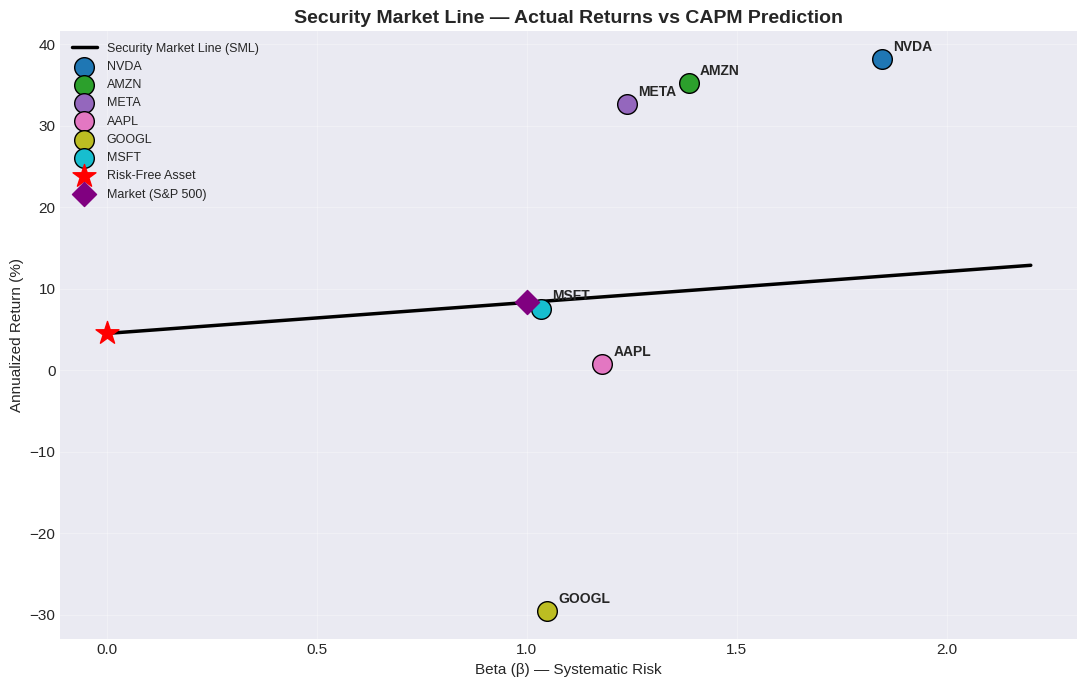

In [13]:
beta_range = np.linspace(0, 2.2, 100)
sml_line = RISK_FREE_RATE + beta_range * market_risk_premium

plt.figure(figsize=(11, 7))
plt.plot(beta_range, sml_line * 100, color='black', linewidth=2.5, label='Security Market Line (SML)', zorder=1)

colors = plt.cm.tab10(np.linspace(0, 1, len(capm_df)))
for (idx, row), c in zip(capm_df.iterrows(), colors):
    plt.scatter(row['Beta'], row['Actual Annualized Return (%)'], s=200, color=c,
                edgecolor='black', zorder=5, label=f"{row['Ticker']}")
    plt.annotate(row['Ticker'], (row['Beta'], row['Actual Annualized Return (%)']),
                 textcoords="offset points", xytext=(8, 6), fontsize=10, fontweight='bold')

plt.scatter(0, RISK_FREE_RATE * 100, marker='*', s=300, color='red', zorder=5, label='Risk-Free Asset')
plt.scatter(1, expected_market_return * 100, marker='D', s=150, color='purple', zorder=5, label='Market (S&P 500)')

plt.title("Security Market Line — Actual Returns vs CAPM Prediction", fontsize=14, fontweight='bold')
plt.xlabel("Beta (β) — Systematic Risk")
plt.ylabel("Annualized Return (%)")
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 11️⃣ Jensen's Alpha — Kya Stock Ne Market Ko Beat Kiya?

$$ \alpha = R_{actual} - E(R_{CAPM}) $$

- **Positive Alpha** → Stock ne apne risk level ke hisaab se **expected se zyada** return diya (outperformed)
- **Negative Alpha** → Stock ne **underperform** kiya apne risk ke hisaab se


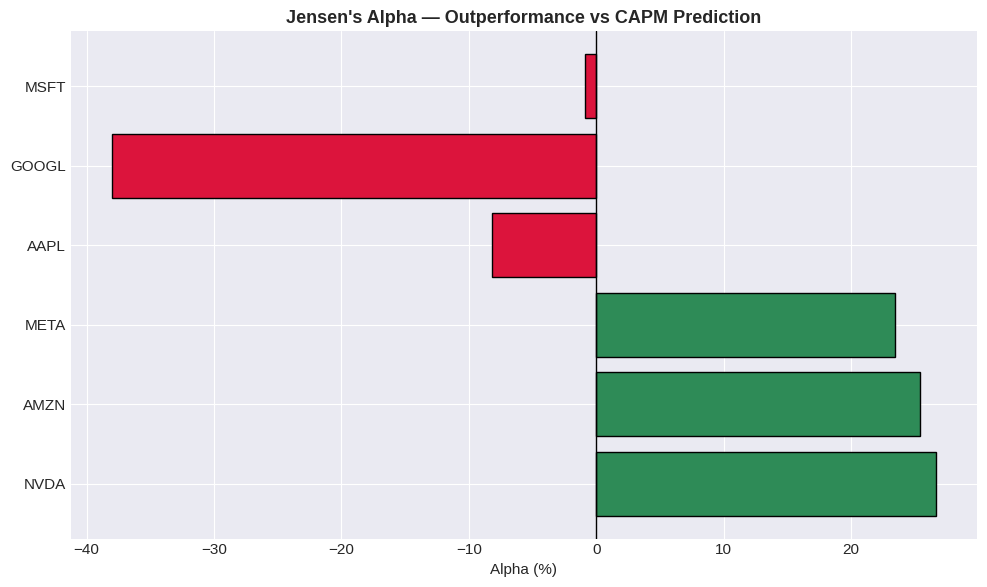

,Ticker,Beta,CAPM Expected Return (%),Actual Annualized Return (%),Jensen's Alpha (%)
4,NVDA,1.847,11.52,38.17,26.65
3,AMZN,1.386,9.77,35.16,25.39
5,META,1.239,9.21,32.63,23.42
0,AAPL,1.180,8.98,0.77,-8.21
2,GOOGL,1.048,8.48,-29.54,-38.02
1,MSFT,1.035,8.43,7.55,-0.88


In [14]:
plt.figure(figsize=(10, 6))
colors_alpha = ['seagreen' if x > 0 else 'crimson' for x in capm_df["Jensen's Alpha (%)"]]
plt.barh(capm_df['Ticker'], capm_df["Jensen's Alpha (%)"], color=colors_alpha, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title("Jensen's Alpha — Outperformance vs CAPM Prediction", fontsize=13, fontweight='bold')
plt.xlabel("Alpha (%)")
plt.tight_layout()
plt.show()

capm_df[['Ticker', 'Beta', 'CAPM Expected Return (%)', 'Actual Annualized Return (%)', "Jensen's Alpha (%)"]]


## 12️⃣ Sharpe Ratio — Risk-Adjusted Performance

Sharpe Ratio batata hai ke aapko **har unit risk (volatility)** ke liye kitna extra return mil raha hai:

$$ \text{Sharpe Ratio} = \frac{R_{portfolio} - R_f}{\sigma_{portfolio}} $$

Higher Sharpe Ratio = better risk-adjusted performance.


In [15]:
sharpe_results = []
for ticker in TICKERS + ['Market_SP500']:
    annual_ret = annual_stats.loc[ticker, 'Annualized Return (%)'] / 100
    annual_vol = annual_stats.loc[ticker, 'Annualized Volatility (%)'] / 100
    sharpe = (annual_ret - RISK_FREE_RATE) / annual_vol
    sharpe_results.append({'Ticker': ticker, 'Sharpe Ratio': round(sharpe, 3)})

sharpe_df = pd.DataFrame(sharpe_results).sort_values('Sharpe Ratio', ascending=False)
sharpe_df


,Ticker,Sharpe Ratio
3,AMZN,0.979
5,META,0.971
4,NVDA,0.937
6,Market_SP500,0.246
1,MSFT,0.108
0,AAPL,-0.130
2,GOOGL,-1.246


## 13️⃣ Portfolio CAPM — Multiple Stocks Ka Combined Beta

Portfolio Beta individual betas ka **weighted average** hota hai:

$$ \beta_{portfolio} = \sum_{i=1}^{n} w_i \beta_i $$

Example: Ek **equal-weighted tech portfolio** banate hain (sab 6 companies mein 1/6 weight).


In [16]:
weights = {ticker: 1/len(TICKERS) for ticker in TICKERS}  # Equal weight

portfolio_beta = sum(weights[t] * beta_df.loc[beta_df['Ticker'] == t, 'Beta (Regression)'].values[0]
                      for t in TICKERS)
portfolio_capm_return = RISK_FREE_RATE + portfolio_beta * market_risk_premium

# Actual portfolio historical return (equal-weighted daily rebalanced approx)
portfolio_daily_returns = simple_returns[TICKERS].mean(axis=1)
portfolio_actual_annual = portfolio_daily_returns.mean() * TRADING_DAYS
portfolio_vol_annual = portfolio_daily_returns.std() * np.sqrt(TRADING_DAYS)
portfolio_sharpe = (portfolio_actual_annual - RISK_FREE_RATE) / portfolio_vol_annual

print("=== Equal-Weighted Big Tech Portfolio ===")
print(f"Weights: {dict((k, round(v,3)) for k,v in weights.items())}\n")
print(f"Portfolio Beta:                  {portfolio_beta:.3f}")
print(f"CAPM Expected Return:             {portfolio_capm_return*100:.2f}%")
print(f"Actual Annualized Return:         {portfolio_actual_annual*100:.2f}%")
print(f"Actual Annualized Volatility:     {portfolio_vol_annual*100:.2f}%")
print(f"Portfolio Sharpe Ratio:           {portfolio_sharpe:.3f}")
print(f"Jensen's Alpha:                   {(portfolio_actual_annual - portfolio_capm_return)*100:.2f}%")


=== Equal-Weighted Big Tech Portfolio ===
Weights: {'AAPL': 0.167, 'MSFT': 0.167, 'GOOGL': 0.167, 'AMZN': 0.167, 'NVDA': 0.167, 'META': 0.167}

Portfolio Beta:                  1.289
CAPM Expected Return:             9.40%
Actual Annualized Return:         14.12%
Actual Annualized Volatility:     21.94%
Portfolio Sharpe Ratio:           0.439
Jensen's Alpha:                   4.72%


## 14️⃣ Risk-Return Map — Volatility vs Return (Bonus Visualization)

Ye chart har company ka **actual risk (volatility)** aur **actual return** dikhata hai — Beta ke bagair bhi ek quick "risk vs reward" comparison.


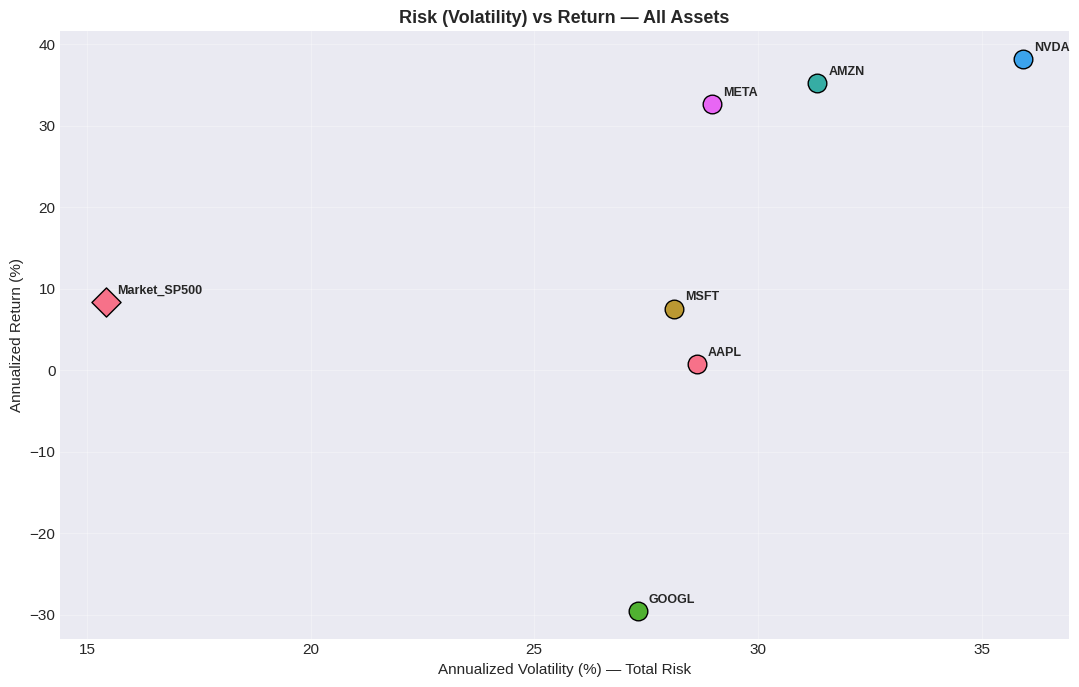

In [17]:
plt.figure(figsize=(11, 7))
for ticker in TICKERS + ['Market_SP500']:
    vol = annual_stats.loc[ticker, 'Annualized Volatility (%)']
    ret = annual_stats.loc[ticker, 'Annualized Return (%)']
    marker = 'D' if ticker == 'Market_SP500' else 'o'
    size = 220 if ticker == 'Market_SP500' else 180
    plt.scatter(vol, ret, s=size, marker=marker, edgecolor='black', label=ticker, zorder=5)
    plt.annotate(ticker, (vol, ret), textcoords="offset points", xytext=(8, 6), fontsize=9, fontweight='bold')

plt.title("Risk (Volatility) vs Return — All Assets", fontsize=13, fontweight='bold')
plt.xlabel("Annualized Volatility (%) — Total Risk")
plt.ylabel("Annualized Return (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 15️⃣ Limitations of CAPM (Real-World Context)

1. **Single-Factor Model** — sirf market risk (Beta) consider karta hai. **Fama-French 3-Factor / 5-Factor models** size, value, profitability, aur investment factors bhi add karte hain jo real returns ko better explain karte hain.
2. **Beta Instability** — jaisa humne rolling beta mein dekha, Beta time ke sath significantly change hoti hai.
3. **Market Portfolio Proxy** — S&P 500 sirf US large-cap stocks hain, **true "market portfolio"** (saari asset classes: bonds, real estate, international stocks, crypto) nahi.
4. **Efficient Market Assumption** — CAPM assume karta hai market efficient hai, lekin behavioral biases, information asymmetry real duniya mein exist karte hain.
5. **Risk-Free Rate Assumption** — "risk-free" asset (jaise T-Bills) ka return bhi inflation aur currency risk se pura immune nahi hota, especially emerging markets (Pakistan) mein.
6. **Historical Data Limitation** — Beta jo humne calculate ki, wo **past** data se hai — future ka guarantee nahi.

### Conclusion

CAPM finance ka ek **foundational framework** hai jo simplistically batata hai ke risk aur return kaise related hain. Real-world equity research, cost of capital calculation, aur portfolio management mein widely use hota hai — lekin ise hamesha **complementary models, judgment, aur current market context** ke sath use karna chahiye.

### 📚 Further Reading:
- William Sharpe (1964) — *"Capital Asset Prices: A Theory of Market Equilibrium"* (Original CAPM Paper)
- Eugene Fama & Kenneth French (1992, 2015) — *Three-Factor* and *Five-Factor Models*
- Zvi Bodie, Alex Kane, Alan Marcus — *"Investments"* (textbook, CAPM chapter)

---
**Made with ❤️ — World-Class CAPM Notebook with Real S&P 500 + Big Tech Data**
